# Real or Fake Image-TESTING PROCESS

In [1]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [2]:
class_names={0:'Fake',1:'Real'}

In [3]:
model=load_model("model/cnn_model_weights.h5")

# Testing 

In [9]:
img = cv.imread("user_input/image.jpg")

In [10]:
gabor_1 = cv.getGaborKernel((18, 18), 1.5, np.pi/4, 5.0, 1.5, 0, 
                            ktype=cv.CV_32F) 
filtered_img_1 = cv.filter2D(img, cv.CV_8UC3, gabor_1)
gabor_2 = cv.getGaborKernel((18, 18), 1.5, np.pi/4, 5.0, 1.5, 0, 
                            ktype=cv.CV_32F)
filtered_img_2 = cv.filter2D(filtered_img_1, cv.CV_8UC3, gabor_2)
cv.imwrite('user_input/test.jpg', filtered_img_2)
img = cv.imread('user_input/test.jpg', 1)
resized_img = np.array(cv.resize(img, (128, 128)))
images = np.ndarray((1, 128, 128, 3), dtype = np.float32)
images[0] = np.reshape(a= resized_img, newshape= (128, 128,3))
np.savez(file='user_input/test',x=images)

(-0.5, 127.5, 127.5, -0.5)

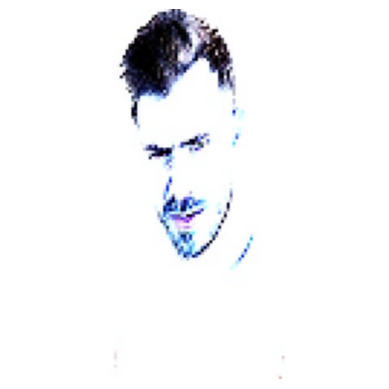

In [11]:
data = np.load('user_input/test.npz')
img = data['x'] / 255
plt.imshow(img[0])
plt.axis("off")

In [12]:
img.shape

(1, 128, 128, 3)

In [13]:
results=model.predict(img)

In [14]:
for i in results:
    print(i)

[0.14076763 0.88485086]


In [15]:
single_result=results[0]

In [16]:
most_likely_class_index =int(np.argmax(single_result))
class_likelihood =single_result[most_likely_class_index]

In [17]:
most_likely_class_index

1

In [18]:
class_label=class_names[most_likely_class_index]

In [19]:
print("Predicted class is{}-Confidence Score: {:.2f}%".format(class_label,class_likelihood))

Predicted class isReal-Confidence Score: 0.88%


# Thank You.....